# Importation et définition de variables globales

In [6]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
import ale_py
import gc
import seaborn as sns
import pickle

from agent.rainbow_agent import DQNAgent as Rainbow

from agent.no_noisy_no_categ_agent import DQNAgent as NoNoisyNoCateg
from reseaux.nn_no_noisy_no_categ_no_duel import Network as NnNoThree
from reseaux.nn_no_noisy_no_categ import Network as NnDueling

from agent.no_noisy_agent import DQNAgent as NoNoisy
from reseaux.nn_no_noisy_no_duel import Network as NnCateg
from reseaux.nn_no_noisy import Network as NnNoNoisy

from utils.processing import show_latest_video

In [5]:
# Environment
env = gym.make("ALE/Freeway-v5", render_mode="rgb_array")

# Set random seed

In [9]:
seed = 777

def seed_torch(seed):
    torch.manual_seed(seed)
    if torch.backends.cudnn.enabled:
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

np.random.seed(seed)
random.seed(seed)
seed_torch(seed)

# Initialisation

In [10]:
# paramètres
num_frames = 200000
memory_size = 100000 #ou 10 000 d'après le code original
batch_size = 128
target_update = 100
epsilon_decay = 1 / 2000
buffer_dir = './buffer_saves'

# Agent

GERER L'ASPECT VIDEO !!!!! ; désactiver, écrasement

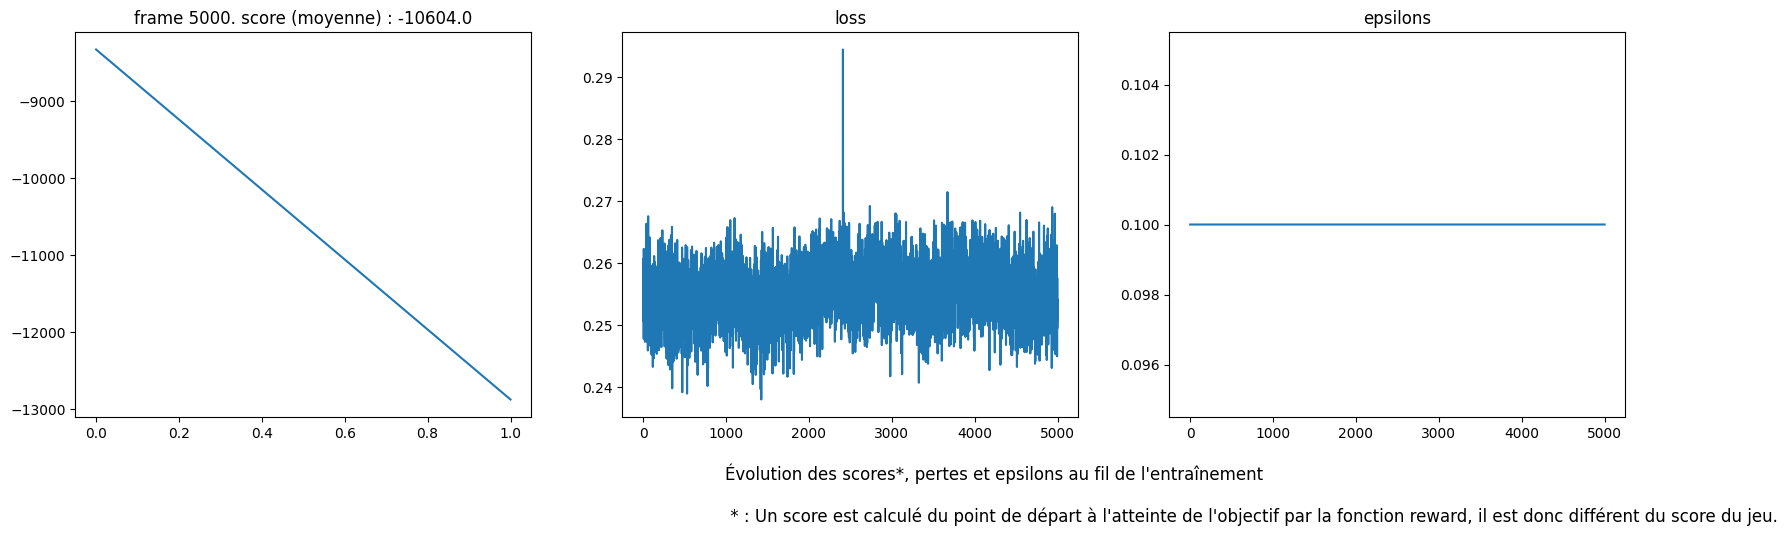

score:  -3710.0


c:\Users\emela\Documents\GitHub\Planif_en_IA\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at c:\Users\emela\Documents\GitHub\Planif_en_IA\corbeille\39 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


score:  -9482.0
Liste sauvegardée : 195000


In [ ]:
#ordre : rainbow, no_three, no_noisy_no_categ, no_noisy_no_duel, no_noisy

#score_agents = np.zeros([2, num_frames], dtype=float)
score_no_noisy = []
score_no_duel = []

# Définition
#agent_rainbow = Rainbow(None, env, memory_size, batch_size, target_update, seed, f'{buffer_dir}/rainbow')
#agent_no_three = NoNoisyNoCateg(None, NnNoThree, env, memory_size, batch_size, target_update, epsilon_decay, seed, f'{buffer_dir}/no_three')
#agent_no_noisy_no_categ = NoNoisyNoCateg(None, NnDueling, env, memory_size, batch_size, target_update, epsilon_decay, seed, f'{buffer_dir}/no_noisy_no_categ')
agent_no_noisy_no_duel = NoNoisy(None, NnCateg, env, memory_size, batch_size, target_update,  epsilon_decay, seed, f'{buffer_dir}/no_noisy_no_duel')
agent_no_noisy = NoNoisy(None, NnNoNoisy, env, memory_size, batch_size, target_update, epsilon_decay, seed, f'{buffer_dir}/no_noisy')

for iter in range(0, num_frames, 5000): 
   
    # Entraînement
    #agent_rainbow.train(iter)
    #agent_no_three.train(iter)
    #agent_no_noisy_no_categ.train(iter)
    agent_no_noisy_no_duel.train(5000)
    agent_no_noisy.train(5000)

    # Test
   #  score_agents[0][iter] = agent_rainbow.test("corbeille/")
   #  score_agents[1][iter] = agent_no_three.test("corbeille/")
   #  score_agents[2][iter] = agent_no_noisy_no_categ.test("corbeille/")
    score_no_duel.append(agent_no_noisy_no_duel.test("corbeille/"))
    score_no_noisy.append(agent_no_noisy.test("corbeille/"))

    #Sauvegarde préventive en cas d'interruption
    if iter % 5000 == 0:
      # Sauvegarde
      with open("score_no_noisy_200000.pkl", "wb") as f:
         pickle.dump(score_no_noisy, f)
      with open("score_no_duel_200000.pkl", "wb") as f:
         pickle.dump(score_no_duel, f)
      print(f"Liste sauvegardée : {iter}")

In [12]:
with open("score_no_noisy_200000.pkl", "wb") as f:
    pickle.dump(score_no_noisy, f)
with open("score_no_duel_200000.pkl", "wb") as f:
    pickle.dump(score_no_duel, f)

In [13]:
agent_no_noisy_no_duel.test("test_200000/no_duel/")
agent_no_noisy.test("test_200000/no_noisy/")

c:\Users\emela\Documents\GitHub\Planif_en_IA\agent\no_noisy_agent.py:203: RuntimeWarning: overflow encountered in scalar add
  mask[i, j] = (a + b + c) / 3 + 50


score:  -6066.0
score:  -14008.0


-14008.0

In [32]:
import pickle

def save_agent(agent, filename: str):
    """Sauvegarde l'agent avec pickle."""
    with open(filename, "wb") as f:
        pickle.dump(agent, f)
    print(f"Agent sauvegardé sous {filename}")

save_agent(agent_no_noisy_no_duel, "agent_no_noisy_no_duel_200000.pkl")


Agent sauvegardé sous agent_no_noisy_no_duel_200000.pkl


In [33]:
# Charger le fichier localement
with open("agent_no_noisy_no_duel_200000.pkl", "rb") as f:
    test_ag = pickle.load(f)

print("Liste chargée :", type(test_ag))  # Vérifie le type de l'objet

Liste chargée : <class 'agent.no_noisy_agent.DQNAgent'>


In [34]:
test_ag.test("ouch")

c:\Users\emela\Documents\GitHub\Planif_en_IA\agent\no_noisy_agent.py:203: RuntimeWarning: overflow encountered in scalar add
  mask[i, j] = (a + b + c) / 3 + 50


score:  -986.0


-986.0

In [ ]:
# Exécutez cette cellule, afin de supprimer les fichiers de buffer_save à la main :
# del agent_rainbow
del agent_no_three
del agent_no_noisy_no_categ
# del agent_no_noisy_no_duel
# del agent_no_noisy

In [ ]:
# Charger le fichier localement
with open("./resultat/score_agents_rainbow_100000.pkl", "rb") as f:
    score_rainbow = pickle.load(f)

# Charger le fichier localement
with open("./resultat/score_agents_no_three_100000.pkl", "rb") as f:
    score_no_three = pickle.load(f)

# Charger le fichier localement
with open("./resultat/score_agents_no_noisy_no_categ_100000.pkl", "rb") as f:
    score_no_noisy_no_categ = pickle.load(f)

# Charger le fichier localement
with open("./resultat/score_agents_no_noisy_no_duel_100000.pkl", "rb") as f:
    score_no_noisy_no_duel = pickle.load(f)

# Charger le fichier localement
with open("./resultat/score_agents_no_noisy_100000.pkl", "rb") as f:
    score_no_noisy = pickle.load(f)


In [13]:
score_agents = [score_rainbow[0], score_no_three[0], score_no_noisy_no_categ[0], score_no_noisy_no_duel[0], score_no_noisy[0]]

In [14]:
with open("score_no_noisy_200000.pkl", "rb") as f:
    score_no_noisy = pickle.load(f)
with open("score_no_duel_200000.pkl", "rb") as f:
    score_no_duel = pickle.load(f)

In [ ]:
liste_frames = np.arange(0, num_frames, 5000)
liste_label = ["no noisy, no dueling", "no noisy"]
# Générer une palette de 5 couleurs harmonieuses
colors = sns.color_palette("deep", n_colors=len(liste_label))


# Création de la figure et du graphe
plt.figure(figsize=(8, 6))
plt.title("Graphe avec " + str(len(liste_label)) + " courbes")


plt.plot(liste_frames, score_no_noisy, color=colors[1], linewidth=2, label=liste_label[1])
plt.plot(liste_frames, score_no_duel, color=colors[0], linewidth=2, label=liste_label[0])


# Ajout de la légende et des labels
plt.xlabel("Num_frames d'entraînement") # QU EST CE QUE NUM FRAMES DANS TRAI?
plt.ylabel("Score obtenu par la fonction reward pour le test")
plt.legend()

# Affichage du graphe
plt.show()

In [12]:
score_rainbow

array([[-27718., -27718., -29908., -29908., -29908., -29908., -29908.,
        -27718., -27718., -29908., -29908., -29908., -29908., -29908.,
        -29908., -29908., -29908., -29908., -29908., -29908.]])

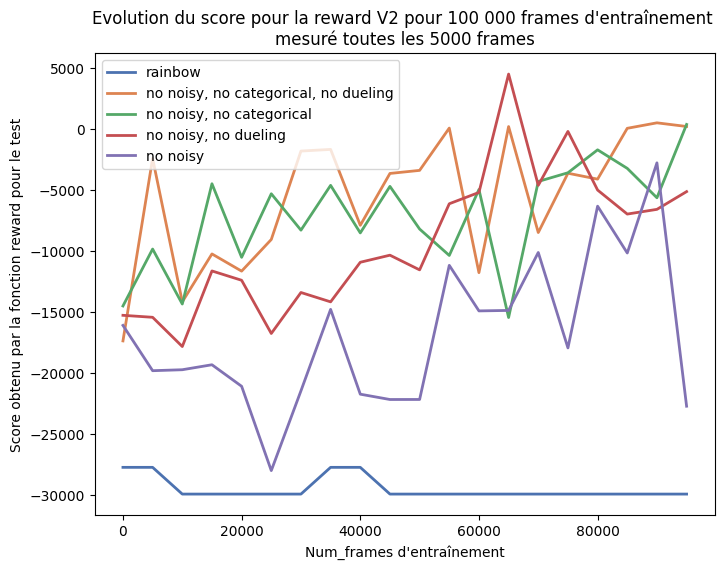

In [18]:
liste_frames = np.arange(0, 100000, 5000)
liste_label = ["rainbow", "no noisy, no categorical, no dueling", "no noisy, no categorical", "no noisy, no dueling", "no noisy"]
# Générer une palette de 5 couleurs harmonieuses
colors = sns.color_palette("deep", n_colors=len(liste_label))


# Création de la figure et du graphe
plt.figure(figsize=(8, 6))
plt.title("Evolution du score pour la reward V2 pour 100 000 frames d'entraînement \nmesuré toutes les 5000 frames")

# Tracer les courbes
for i in range(len(liste_label)):
    plt.plot(liste_frames, score_agents[i], label=liste_label[i], color=colors[i], linewidth=2)

# Ajout de la légende et des labels
plt.xlabel("Num_frames d'entraînement") # QU EST CE QUE NUM FRAMES DANS TRAI?
plt.ylabel("Score obtenu par la fonction reward pour le test")
plt.legend()

# Affichage du graphe
plt.show()

In [20]:
np.argmax(score_no_noisy_no_duel[0])

np.int64(13)

In [ ]:
# Charger le fichier localement
with open("nb_crashes_no_noisy_no_duel_100000.pkl", "rb") as f:
    crash_no_duel = pickle.load(f)

In [25]:
crash_no_duel[0][13]

np.int64(15)